## 🎯 Problem Statement
Early detection of brain tumors is critical in medical imaging.
In this notebook, we explore how U-Net can segment tumor regions
from MRI scans and analyze where it works well and where it fails.


In [1]:
import os, random, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()
print("Device:", DEVICE)

Device: cuda


## 📦 Dataset Overview
Before training the model, we explore the dataset to understand
image structure, mask quality, and class distribution.


In [2]:
DATA_DIR = "/kaggle/input/brain-mri-images-for-brain-tumor-detection"

classes = ["yes", "no"]

data = []
for label, cls in enumerate(classes):
    folder = os.path.join(DATA_DIR, cls)
    for file in os.listdir(folder):
        data.append((os.path.join(folder, file), label))

df = pd.DataFrame(data, columns=["path", "label"])
print(df.head())

                                                path  label
0  /kaggle/input/brain-mri-images-for-brain-tumor...      0
1  /kaggle/input/brain-mri-images-for-brain-tumor...      0
2  /kaggle/input/brain-mri-images-for-brain-tumor...      0
3  /kaggle/input/brain-mri-images-for-brain-tumor...      0
4  /kaggle/input/brain-mri-images-for-brain-tumor...      0


## 👁️ Visual Exploration
We visualize MRI images, ground truth masks, and model predictions
to build intuition about the segmentation task.


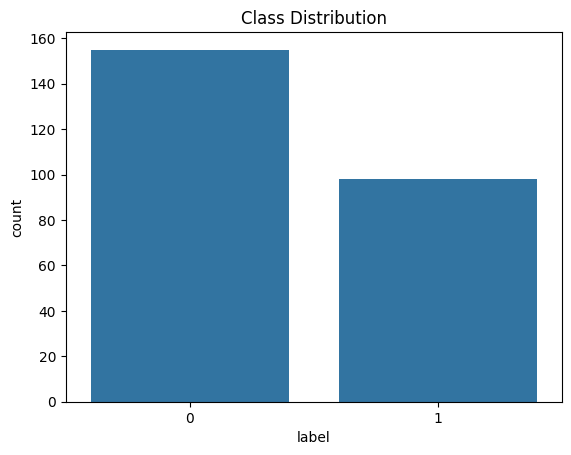

label
0    0.612648
1    0.387352
Name: proportion, dtype: float64


In [3]:
sns.countplot(x=df["label"])
plt.title("Class Distribution")
plt.show()

print(df['label'].value_counts(normalize=True))

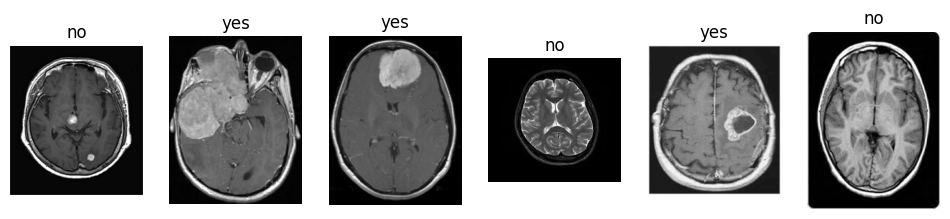

In [4]:
def show_samples(df, n=6):
    sample = df.sample(n)
    plt.figure(figsize=(12,4))
    for i, row in enumerate(sample.itertuples()):
        img = cv2.imread(row.path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.title(classes[row.label])
        plt.axis("off")
    plt.show()

show_samples(df)

In [5]:
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42
)

In [6]:
train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor()
])

val_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [7]:
class BrainDataset(Dataset):
    def __init__(self, df, tfms=None):
        self.df = df.reset_index(drop=True)
        self.tfms = tfms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = cv2.imread(row.path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.tfms:
            img = self.tfms(img)

        label = torch.tensor(row.label).long()
        return img, label

In [8]:
train_ds = BrainDataset(train_df, train_tfms)
val_ds   = BrainDataset(val_df, val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

In [9]:
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)

model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s] 


In [10]:
class_weights = torch.tensor([1.2, 0.8]).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

In [11]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [12]:
def validate(model, loader):
    model.eval()
    total_loss = 0
    preds, targets = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds.extend(torch.argmax(outputs,1).cpu().numpy())
            targets.extend(labels.cpu().numpy())

    return total_loss/len(loader), preds, targets

In [13]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, preds, targets = validate(model, val_loader)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

Epoch 1
Train Loss: 0.6286
Val Loss: 0.6301
Epoch 2
Train Loss: 0.4850
Val Loss: 0.5892
Epoch 3
Train Loss: 0.3877
Val Loss: 0.5296
Epoch 4
Train Loss: 0.3111
Val Loss: 0.4698
Epoch 5
Train Loss: 0.2401
Val Loss: 0.4168
Epoch 6
Train Loss: 0.2225
Val Loss: 0.3862
Epoch 7
Train Loss: 0.1756
Val Loss: 0.3620
Epoch 8
Train Loss: 0.1372
Val Loss: 0.3256
Epoch 9
Train Loss: 0.1301
Val Loss: 0.2949
Epoch 10
Train Loss: 0.0869
Val Loss: 0.2895


In [14]:
print(classification_report(targets, preds))

              precision    recall  f1-score   support

           0       0.83      0.94      0.88        31
           1       0.88      0.70      0.78        20

    accuracy                           0.84        51
   macro avg       0.85      0.82      0.83        51
weighted avg       0.85      0.84      0.84        51



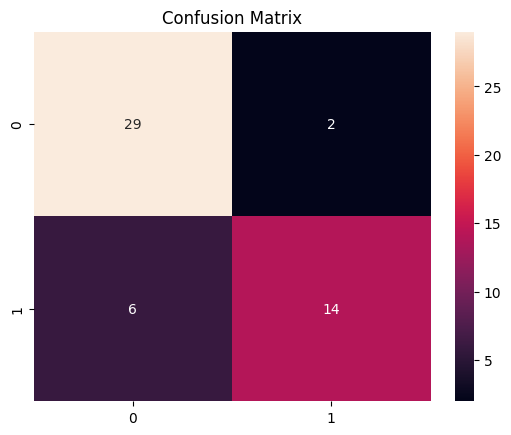

In [15]:
cm = confusion_matrix(targets, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [16]:
# multi-class AUC
from sklearn.preprocessing import label_binarize

y_true = label_binarize(targets, classes=[0,1])
y_pred = label_binarize(preds, classes=[0,1])

print("ROC-AUC:", roc_auc_score(y_true, y_pred))

ROC-AUC: 0.817741935483871


In [17]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x):
        self.model.eval()
        output = self.model(x)
        pred_class = output.argmax(dim=1)

        self.model.zero_grad()
        output[0, pred_class].backward()

        grads = self.gradients[0].cpu().numpy()
        acts = self.activations[0].cpu().numpy()

        weights = np.mean(grads, axis=(1,2))
        cam = np.zeros(acts.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        return cam

In [18]:
target_layer = model.features[-1]
cam = GradCAM(model, target_layer)

In [19]:
def show_cam(img, heatmap):
    img_np = img.permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = heatmap * 0.4 + img_np * 255

    plt.imshow(overlay.astype(np.uint8))
    plt.axis("off")

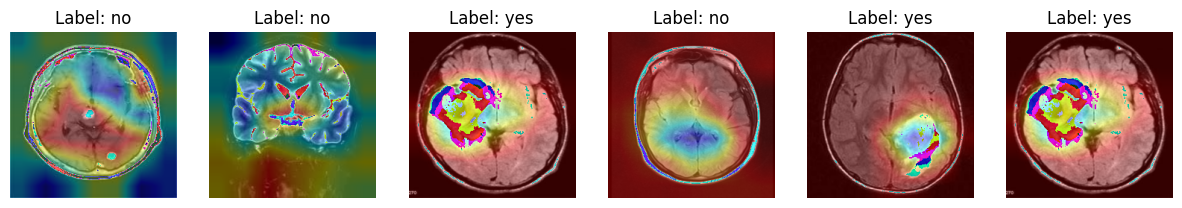

In [20]:
def show_gradcam_samples(model, dataset, n=6):
    model.eval()
    idxs = np.random.choice(len(dataset), n)

    plt.figure(figsize=(15,5))

    for i, idx in enumerate(idxs):
        img, label = dataset[idx]
        heatmap = cam.generate(img.unsqueeze(0).to(DEVICE))

        plt.subplot(1,n,i+1)
        show_cam(img, heatmap)
        plt.title(f"Label: {classes[label]}")

    plt.show()

show_gradcam_samples(model, val_ds)

In [21]:
wrong = []

for i in range(len(preds)):
    if preds[i] != targets[i]:
        wrong.append(i)

print("Total errors:", len(wrong))

Total errors: 8


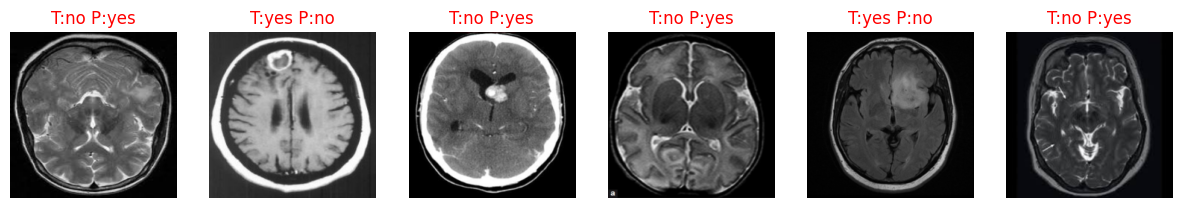

In [22]:
def show_misclassified(model, dataset, n=6):
    model.eval()
    samples = []

    for i in range(len(dataset)):
        img, label = dataset[i]
        with torch.no_grad():
            pred = torch.argmax(model(img.unsqueeze(0).to(DEVICE)),1).item()

        if pred != label:
            samples.append((img, label, pred))

    samples = random.sample(samples, min(n, len(samples)))

    plt.figure(figsize=(15,5))
    for i, (img, label, pred) in enumerate(samples):
        img_np = img.permute(1,2,0).cpu().numpy()

        plt.subplot(1,n,i+1)
        plt.imshow(img_np)
        plt.title(f"T:{classes[label]} P:{classes[pred]}", color="red")
        plt.axis("off")

    plt.show()

show_misclassified(model, val_ds)

# This study demonstrates that EfficientNet achieves high accuracy in brain tumor classification.

Grad-CAM analysis shows that the model focuses on tumor regions in correctly classified samples,
while misclassifications often occur in low-contrast images.

Future work includes:
- 3D MRI modeling
- Multi-modal fusion
- Attention-based architectures